# Linear Regression using Python

Objective:
>In this project, you will use Python to analyze the relationship between Height (in inches) and Weight (in pounds) using Simple Linear Regression (SLR).

You are given a CSV file containing two columns:

* Height (inches)
* Weight (pounds)
  

Your goal is to explore the data, compute regression parameters manually, run a regression model using Python, and evaluate how well height predicts weight.


Tasks:

1) Inspect the data  
  a. Print first 10 rows of data set  
  b. Print summary statistics (mean, min, max, standard deviation, etc.).  
  c. Plot a scatter plot of Height vs Weight  
1) Manual Regression Computation (No Regression Libraries), Using Python and formulas:  
  a. Compute mean height and mean weight  
  b. Compute $\hat{\theta}_1$ and $\hat{\theta}_0$ based on their formulas  
  c. Compute residual Sum of Squares (RSS)  
1) Linear Regression using Statsmodels - Use Python’s statsmodels library to run the regression and print:  
  a. Estimated $\hat{\theta}_1$ and $\hat{\theta}_0$  
  b. Standard errors  
  c. P-values  
  d. 95% confidence intervals  
1) Goodness of fit - Write Python code to compute and plot:  
  a. R2  
  b. Standard error of regression  
  c. Residual plot (residuals vs fitted values)  

## Task 1: Inspect the data

In [20]:
import pandas as pd

data = pd.read_csv("weight-height.csv")
data = data.rename(columns={"Height(Inches)": "height", "Weight(Pounds)": "weight"})
print("First 10 Rows of Dataset:", data.head(10), sep="\n")

First 10 Rows of Dataset:
      height      weight
0  73.847017  241.893563
1  68.781904  162.310473
2  74.110105  212.740856
3  71.730978  220.042470
4  69.881796  206.349801
5  67.253016  152.212156
6  68.785081  183.927889
7  68.348516  167.971111
8  67.018950  175.929440
9  63.456494  156.399676


In [21]:
print("Summary Statistics", data.describe(), sep="\n")

Summary Statistics
             height        weight
count  10000.000000  10000.000000
mean      66.367560    161.440357
std        3.847528     32.108439
min       54.263133     64.700127
25%       63.505620    135.818051
50%       66.318070    161.212928
75%       69.174262    187.169525
max       78.998742    269.989698


<Axes: title={'center': 'Height VS Weight'}, xlabel='height', ylabel='weight'>

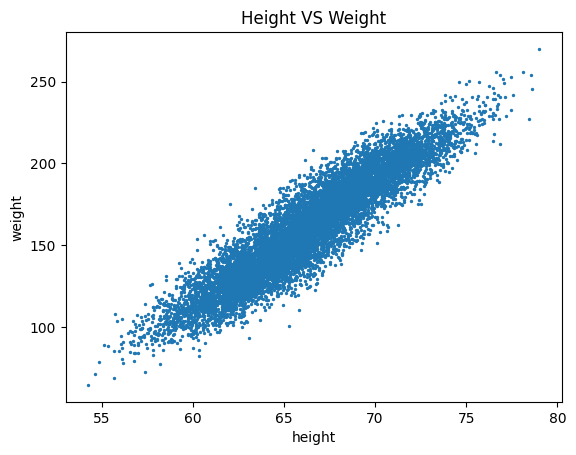

In [22]:
data.plot.scatter(x="height", y="weight", s=2, title="Height VS Weight")

## Task 2: Manual Regression Computation, Using Python and formulas

In [ ]:
# Calculate mean height and weight
mean_height = data["height"].mean()
mean_weight = data["weight"].mean()
print(f"Mean Height:{mean_height:.2f}\nMean Weight:{mean_weight:.2f}")

Mean Height:66.37
Mean Weight:161.44


In [50]:
# Calculate theta hat 1 and theta hat 0
renamed_data = data.rename(columns={"height": "x", "weight": "y"}).copy()
renamed_data["x_bar"] = renamed_data["x"].mean()
renamed_data["y_bar"] = renamed_data["y"].mean()
renamed_data["xi-xbar"] = renamed_data["x"] - renamed_data["x_bar"]
renamed_data["y1-ybar"] = renamed_data["y"] - renamed_data["y_bar"]

numerator = (renamed_data["xi-xbar"] * renamed_data["y1-ybar"]).sum()
denominator = (renamed_data["xi-xbar"] ** 2).sum()

theta_hat_1 = numerator / denominator

theta_hat_0 = mean_weight - (theta_hat_1 * mean_height)

print(f"Theta hat 1: {theta_hat_1}\nTheta hat 0: {theta_hat_0}")

Theta hat 1: 7.717287640838619
Theta hat 0: -350.73719181541594


In [52]:
# Compute residual sum of squares
slope = theta_hat_1
intercept = theta_hat_0

renamed_data["yhat"] = (slope * renamed_data["x"]) + intercept
renamed_data["(yi-yhat)^2"] = (renamed_data["y"] - renamed_data["yhat"]) ** 2
rss = renamed_data["(yi-yhat)^2"].sum()
print(f"Residual Sum of Squares: {rss:.2f}")

Residual Sum of Squares: 1492934.84


## Task 3: Linear Regression using Statsmodels - Use Python’s statsmodels library to run the regression and print:  


In [ ]:
import statsmodels.api as sm

# Define X and y
y = renamed_data["y"]
X = sm.add_constant(renamed_data["x"])

# Fit model
model = sm.OLS(y, X)
results = model.fit()

# Access the coefficients
theta_hat_0_sm = results.params["const"]
theta_hat_1_sm = results.params["x"]

conf_int = results.conf_int()
conf_int.columns = ["lower_95", "upper_95"]

Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                 5.904e+04
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:43:25   Log-Likelihood:                -39219.
No. Observations:               10000   AIC:                         7.844e+04
Df Residuals:                    9998   BIC:                         7.846e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -350.7372      2.111   -1

In [79]:
print(f"Estimated Slope: {theta_hat_1_sm}\n")
print(f"Estimated Intercept: {theta_hat_0_sm}\n")
print(f"Standard Errors:\n {results.bse}\n")
print(f"P-Values:\n {results.pvalues}\n")
print(f"95% Confidence Intervals:\n {conf_int}")

Estimated Slope: 7.717287640838608

Estimated Intercept: -350.73719181541566

Standard Errors:
 const    2.111486
x        0.031762
dtype: float64

P-Values:
 const    0.0
x        0.0
dtype: float64

95% Confidence Intervals:
          lower_95    upper_95
const -354.876129 -346.598255
x        7.655028    7.779547


## Task 4: Goodness of Fit

In [81]:
print(f"R2: {results.rsquared}\n")
print(f"Standard error of regression:\n {(results.mse_resid)**0.5}")

R2: 0.8551742120552468

Standard error of regression:
 12.219793313701299


Residual Plot

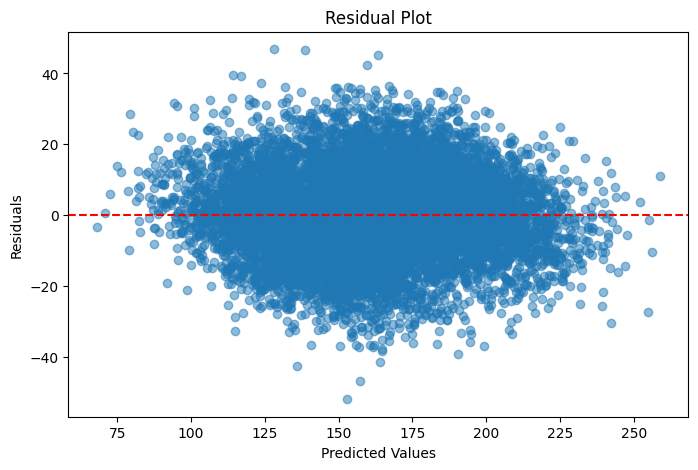

In [61]:
import matplotlib.pyplot as plt

y_pred = results.predict(X)
residuals = y - y_pred

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Analysis
A residual plot shows how far each observed weight is from its predicted value based on height. In this dataset, the residuals scatter randomly around zero, indicating the linear model is appropriate and no major pattern or curvature remains unexplained.  
We can say that height predicts weight reasonably well in this case. The relationship is strongly linear, the residuals show no major patterns, and the R^2 value (0.85) indicates that about 85% of the variation in weight is explained by height.